### Q1

In [ ]:
# def simulate_single_server(T, lmda, g): 
#     '''
#     Simulating M/G/1/infinity/FIFO queue
#     Args:
#         T (float): total time that the system is alive (closing time of the system assuming start time = 0)
#         lmda (float): rate of arrival into the system
#         g: distribution of the service time
#     '''

#     def get_Ts(s, lmda):
#         u = np.random.rand()
#         Ts = s+1/lmda*math.log(1/u)
#         return Ts

#     def generate_Y(g):
#         h = lambda x: math.exp(-x)
#         xstar = 2/39 # computed on paper (where (g/h)' = 0)
#         c = g(xstar)/h(xstar)
#         while(True):
#             u1 = np.random.rand()
#             l = -math.log(u1)
#             u2 = np.random.rand()
#             if(u2 <= (g(l)/h(l))/c):
#                 y = l
#                 break
#         return y

#     # Start time (0), End time (T), Arrival distribution, and Service distribution are specific to the system (they don't change with iterations)
#     # Initialization
#     t = 0
#     n = 0
#     Na = 0 # Number of arrivals
#     A = [] # Arrival times
#     Nd = 0 # Number of departures
#     D = [] # Departure times
#     T0 = get_Ts(0, lmda)
#     ta = T0
#     td = sys.maxsize # to model infinity
    
#     # Running the system
#     while(True):
#         if(ta<=td and ta<=T): # ta = min(ta, td, T)
#             t = ta
#             Na = Na+1
#             n = n+1
#             Tt = get_Ts(t, lmda) # generate Tt
#             ta = Tt
#             if(n==1):
#                 Y = generate_Y(g)
#                 td = t+Y
#             A.append(t)# A(Na) = t # A should be a vector

#         elif(td<ta and td<=T):
#             t = td
#             n = n-1
#             Nd = Nd+1
#             if(n==0):
#                 td = sys.maxsize
#             else:
#                 Y = generate_Y(g)
#                 td = t+Y
#             D.append(t) # D(Nd) = t # so should be D
#         elif(T<min(ta, td)):
#             break

#     return A, D

In [ ]:
def simulate_single_server(T, lmda, service_distribution_option, service_discipline_option): 
    '''
    Simulating M/G/1/infinity/(FIFO or PS) queue
    Args:
        T (float): total time that the system is alive (closing time of the system assuming start time = 0)
        lmda (float): rate of arrival into the system
        service_distribution_option (int): choice of the service time distribution; should be one of {1, 2, 3};
            (1-> Erlang-2,2; 2-> Exp-1; 3-> Hyperexp-(0.1,1/9),(0.9,9))
        service_discipline_option (int, {1, 2}): choice of service discipline; should be from {1, 2}; (1: FIFO, 2: PS)
    Returns:
        2 lists, one containing the arrival times and the other containing departure times (list[float], list[float])
    '''
    if(service_discipline_option not in [1, 2]):
        raise Exception("Service discipline option can only be 1 or 2!")
    
    def simulate_arrival(lmda):
        '''
        Simulate poisson arrival @lmda
        '''
        u = np.random.rand()
        return 1/lmda*math.log(1/u)
    
    def generate_job_size(option):
        '''
        Generate service time for a job using the given option for its distribution
        '''
        if(option == 1): # erlang-2,2 => sum of 2 iid exponentials of rate 2
            u1 = np.random.rand()
            u2 = np.random.rand()
            lmda = 2
            return 1/lmda*math.log(1/u1) + 1/lmda*math.log(1/u2)
        elif(option == 2): # exponential
            lmda = 1
            u = np.random.rand()
            return 1/lmda*math.log(1/u)
        elif(option == 3): # hyperexponential
            u1 = np.random.rand()
            if(u1<0.1): # with probability 0.1, exponential(1/9)
                lmda = 1/9
            else:
                lmda = 9 # with probability 0.9, exponential(9)
            u2 = np.random.rand()
            return 1/lmda*math.log(1/u2)
        else:
            raise Exception("Only the service distributions mentioned in the question supported as of now!")
        
    def sort(s, v):
        '''
        puts s into the sorted vector v in a sorted format
        '''
        l = len(v)
        i = 0
        while(i<l and v[i]<s):
                i += 1
        # first i where v[i]>=s
        return v[:i] + [s] + v[i:]

    # Initializing state variables
    Na = 0
    Nd = 0
    n = 0
    t = 0
    td = sys.maxsize
    A = []
    D = []
    S = []

    # Initializing time variables
    delta = simulate_arrival(lmda)
    ta = t+delta

    while(True):
        te = min(ta, td, T)
        if(te == ta):
            if(service_discipline_option == 1):
                t = te
                Na += 1
                n += 1
                if(n == 1):
                    delta = generate_job_size(service_distribution_option)
                    td = t + delta
                A.append(t)# A(Na) = t # A should be a vector
                delta = simulate_arrival(lmda) 
                ta = t + delta
            elif(service_discipline_option == 2):
                if(n==0):
                    pass
                else:
                    i = 0
                    while(i < n):
                        S[i] -= (ta-t)/n
                        i += 1
                t = te
                A.append(t)
                Na += 1
                n += 1
                X = generate_job_size(service_distribution_option) # job size
                S = sort(X, S)
                assert(len(S) == n)
                td = t + n*S[0]
                # Next arrival
                delta = simulate_arrival(lmda)
                ta = t + delta
        elif(te == td):
            if(service_discipline_option == 1):
                t = te
                n -= 1
                Nd -= 1
                if(n==0):
                    td = sys.maxsize
                else:
                    delta = generate_job_size(service_distribution_option)
                    td = t + delta
                D.append(t) # D(Nd) = t # so should be D
            elif(service_discipline_option == 2):
                R = S[0]
                i = 0
                while(i < n-1):
                    S[i] = S[i+1] - R
                    i += 1
                S = S[:n-1]
                t = te
                D.append(t)
                n -= 1
                Nd += 1
                assert(len(S) == n)
                if(n==0):
                    td = sys.maxsize
                else:
                    td = t + n*S[0]
        else:
            # stop as soon as T is reached
            return A, D

In [ ]:
# # populate NA using A
# na = 0
# i = 0
# j = 0
# while(i<k):
#     while(i<k and i*0.2<A[j]):
#         NA[i] = na
#         i += 1
#     # Suppose 2 arrivals in close context => will be taken care of in the next iteration
#     if(i*0.2>=A[j]):
#         # an arrival at A[j] that needs to be reflected in the times henceforth
#         na += 1
#         # For the next arrival, move to next A[j]
#         j += 1
#     if(j == len(A)):
#         while(i<k):
#             NA[i] = na
#             i += 1



# # populate ND using D
# nd = 0
# i = 0
# j = 0
# while(i<k):
#     while(i<k and i*0.2<D[j]):
#         ND[i] = nd
#         i += 1
#     if(i*0.2 >= D[j]):
#         nd += 1
#         j += 1
#     if(j == len(D)):
#         while(i<k):
#             ND[i] = nd
#             i += 1

In [ ]:
# For subplots

for service_distribution_option in service_distribution_option_mapping.keys():
    fig, ax = plt.subplots(1, len(service_discipline_option_mapping.keys()), figsize = [12, 4], sharey = True)
    for service_discipline_option in service_discipline_option_mapping.keys():
        num_people = np.zeros(k)
        for _ in range(num_iters):
            A, D = simulate_single_server(T, lmda, service_distribution_option, service_discipline_option)
            NA = populate_time_vector(A, k)
            ND = populate_time_vector(D, k)
            num_people += NA - ND
        num_people /= num_iters
        ax[service_discipline_option-1].plot(Tvec, num_people, label = service_discipline_option_mapping[service_discipline_option])
        ax[service_discipline_option-1].legend()
        ax[service_discipline_option-1].set_xlabel("Time")
    fig.supylabel("Mean number of people in the system")
    fig.suptitle(f"Service Distribution = {service_distribution_option_mapping[service_distribution_option]}")
    plt.tight_layout()
    plt.show()

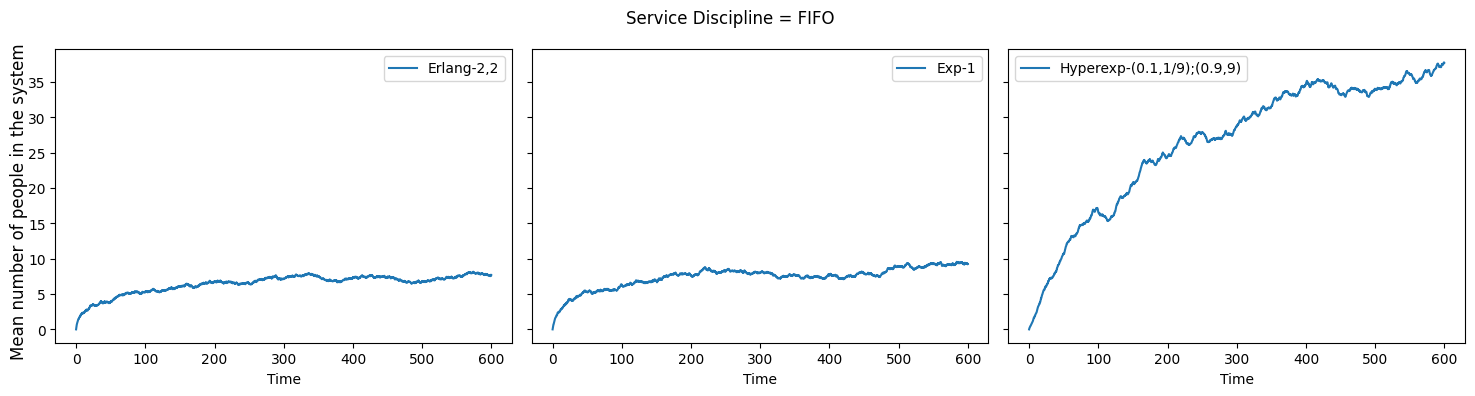

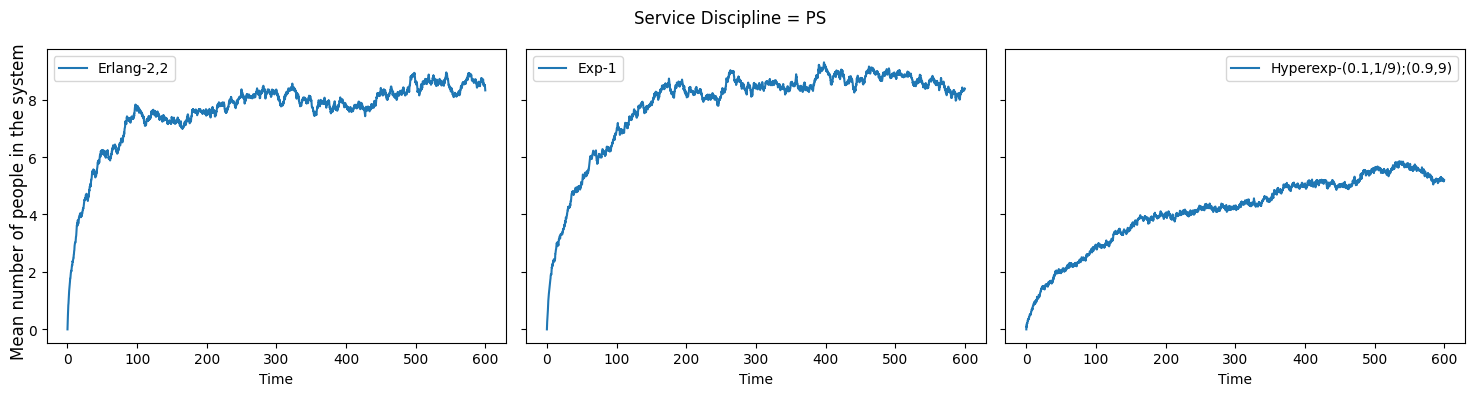

In [ ]:
for service_discipline_option in service_discipline_option_mapping.keys():
    fig, ax = plt.subplots(1, len(service_distribution_option_mapping.keys()), figsize = [15, 4], sharey = True)
    for service_distribution_option in service_distribution_option_mapping.keys():
        num_people = np.zeros(k)
        for _ in range(num_iters):
            A, D = simulate_single_server(T, lmda, service_distribution_option, service_discipline_option)
            NA = populate_time_vector(A, k)
            ND = populate_time_vector(D, k)
            num_people += NA - ND
        num_people /= num_iters
        ax[service_distribution_option-1].plot(Tvec, num_people, label = service_distribution_option_mapping[service_distribution_option])
        ax[service_distribution_option-1].legend()
        ax[service_distribution_option-1].set_xlabel("Time")
    fig.supylabel("Mean number of people in the system")
    fig.suptitle(f"Service Discipline = {service_discipline_option_mapping[service_discipline_option]}")
    plt.tight_layout()
    plt.show()

### Q3

In [ ]:
# Run 2
output = np.zeros((ln, 4))
for i in range(ln):
    n = nvec[i]
    Xn = generate_Xn(p, n)
    output[i][0] = n
    output[i][1] = Xn
    output[i][2] = n/(n+Xn)
    output[i][3] = (n-1)/(n-1+Xn)

output = pd.DataFrame(output, index = nvec, columns = ["n", "Xn", "n/(n+Xn)", "(n-1)/(n-1+Xn)"])
print(output)

### Q4

In [ ]:
#? Make more efficient (one RV being wasted everytime)
def generate_gaussian(mu, sigma):
    '''
    Generate 2 normally distributed independent random variables using box muller method
    Args:
        mu (float): mean (loc) of the random variables
        sigma (float): standard deviation (scale) of the random variables; should be > 0
    Returns:
        a realization of the random variable with the required distribution (float)
    '''
    while(True):
        u1 = np.random.rand()
        v1 = 2*u1 - 1
        u2 = np.random.rand()
        v2 = 2*u2 - 1
        s = v1**2 + v2**2
        if(s<=1):
            break
    x = math.sqrt(-2*math.log(s)/s)*v1
    x = x*sigma + mu
    y = math.sqrt(-2*math.log(s)/s)*v2
    y = y*sigma + mu
    return x

In [ ]:
def get_option_value(S0, K, r, mu, sigma, T, type_of_option, num_iters = 10, delta_t = 1e-5):
    '''
    Compute (using simulation) the option value
    Args:
        S0 (float): present stock price
        K (float): strike price
        r (float): riskfree interest rate
        mu (float): guaranteed yield
        sigma (float): volatility of the stock (the underlying)
        T (float): Time to maturity
        type_of_option (int): the type of option for which to find value; should be one of {1, 2, 3};
        (European -> 1, Asian -> 2, Lookback -> 3; value will differ due to difference in their payoffs)
        num_iters (int, default = 10): number of iterations to run (to compute expected value)
        delta_t (float, default = 1e-5): the step size used while simulating brownian motion paths
    Returns:
        the value of the option (float)
    '''
    num_steps = int(T/delta_t)
    value = 0
    for _ in range(num_iters):
        # generate final price
        price = S0
        price_term = 0
        for _ in range(num_steps):
            w = generate_gaussian(0, math.sqrt(delta_t))
            price = price*math.exp(sigma*w + (mu-sigma**2/2)*delta_t)
            if(type_of_option == 2):
                price_term += price*delta_t/T
            elif(type_of_option == 3):
                price_term = max(price_term, price)
            elif(type_of_option != 1):
                raise Exception("type_of_option can only take a value from the set {1, 2, 3}!")
        if(type_of_option == 1):
            price_term = price
        # generate payoff
        payoff = max(price_term - K, 0)
        # Discounting payoff
        t1 = (r-mu)*generate_gaussian(0,math.sqrt(T))/sigma
        t2 = (r+(mu-r)**2/(2*sigma*sigma))*T
        value += payoff*math.exp(t1 - t2)
    # Taking expectation (or average)
    value = value/num_iters
    return value